In [208]:
%%capture
%load_ext autoreload
%autoreload 2

In [209]:
import sys
sys.path.append('../utils')

import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

from reporting import performance_report, get_summary_stats, print_summary_stats
from metrics import get_annualized_mean_return, get_drawdown, get_periodic_correlation, get_correlation_std_error, get_rolling_correlation
from plotting import set_date_ticks

plt.style.use('../utils/plot-style.rc')

In [173]:
prices_daily   = pd.read_parquet('./data/daily-etf-prices.parquet')
prices_monthly = pd.read_parquet('./data/monthly-etf-prices.parquet')
rfr_monthly    = pd.read_parquet('./data/monthly-rfr.parquet')

returns_daily   = prices_daily.pct_change().dropna(how='all')
returns_monthly = prices_monthly.pct_change().dropna(how='all')
excess_returns  = returns_monthly - rfr_monthly.values.reshape(-1,1)

## All US Equity (SPY)
Before any optimization let's take a baseline of a passive ETF investor that just holds a portfolio of large cap US equities with the SPY ETF. Returns are strong but also see quite a bit of volatility and very big drawdown in 2008.

     CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
--------------------------------------------------------
SPY   10.68        14.87            -50.78        0.65  


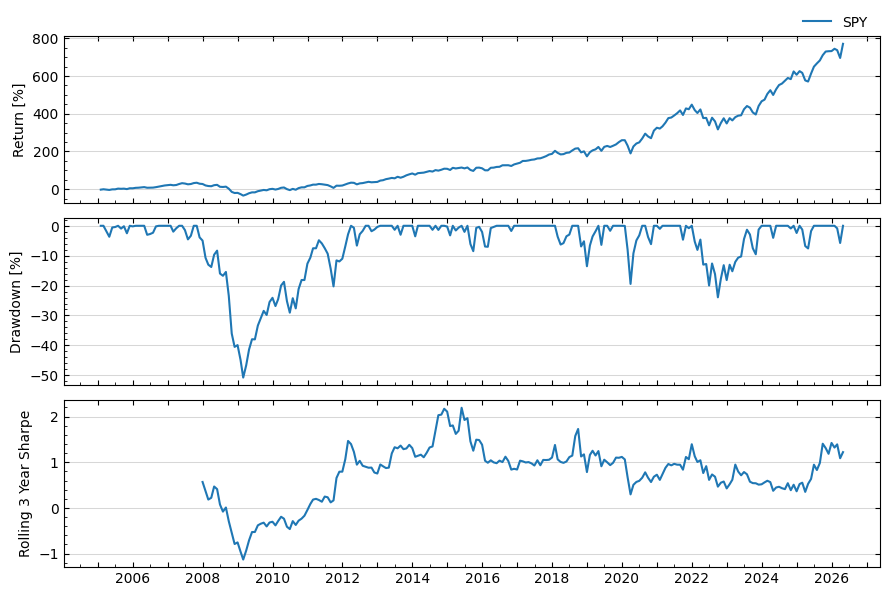

In [174]:
_ = performance_report(returns_monthly[['SPY']], risk_free_returns=rfr_monthly)

## Define a Universe of Assets
Can we do better by instead holding a more diversified portfolio of assets? Let's see. We can use a few ETFs to represent different asset classes a retail investor has access to. For a baseline we choose:

<center>

| Ticker | Description |
| :--------: | :--------: |
| SPY    | Large cap US equities |
| VNQ    | US REITs (Real Estate Investment Trusts) |
| GLD    | Gold   |
| LQD    | Investment grade corporate bonds   |
| TLT    | Long-term treasuries   |

</center>

As part of the optimization we need to be able to estimate correlations / covariances. We are using return data at a monthly time scale however to improve our estimate of covariance we use daily data to have more samples. This is demonstrated in the correlation heatmaps shown below.

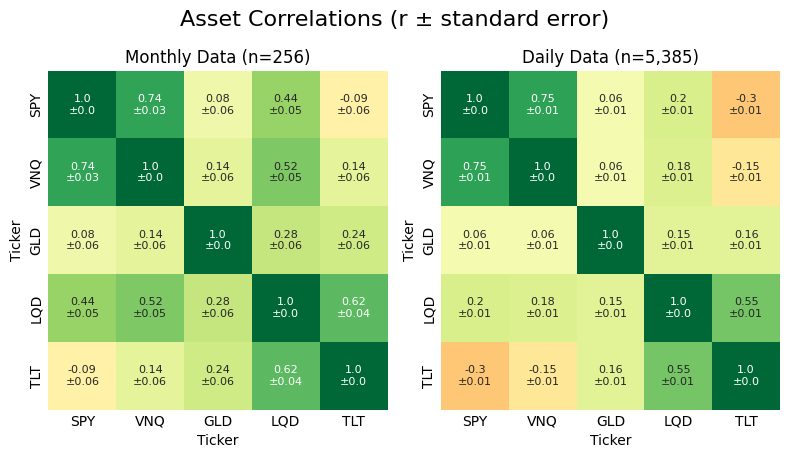

In [175]:
universe     = ['SPY', 'VNQ', 'GLD', 'LQD', 'TLT']

corr_monthly  = returns_monthly[universe].corr()
se_monthly    = get_correlation_std_error(returns_monthly[universe])
annot_monthly = corr_monthly.round(2).astype(str) + '\n±' + se_monthly.round(2).astype(str)

corr_daily   = returns_daily[universe].corr()
se_daily     = get_correlation_std_error(returns_daily[universe])
annot_daily  = corr_daily.round(2).astype(str) + '\n±' + se_daily.round(2).astype(str)

fig, axs = plt.subplots(ncols=2, figsize=(8, 4.5))

sns.heatmap(corr_monthly, vmax=1, vmin=-1, square=True, cbar=False, cmap='RdYlGn',
            annot=annot_monthly, fmt='', annot_kws={'fontsize': 8}, ax=axs[0])
axs[0].set_title(f'Monthly Data (n={len(returns_monthly):,})')
axs[0].tick_params(axis='both', length=0)

sns.heatmap(corr_daily, vmax=1, vmin=-1, square=True, cbar=False, cmap='RdYlGn',
            annot=annot_daily, fmt='', annot_kws={'fontsize': 8}, ax=axs[1])
axs[1].set_title(f'Daily Data (n={len(returns_daily):,})')
axs[1].tick_params(axis='both', length=0)

fig.suptitle('Asset Correlations (r ± standard error)')
fig.tight_layout()
plt.show()

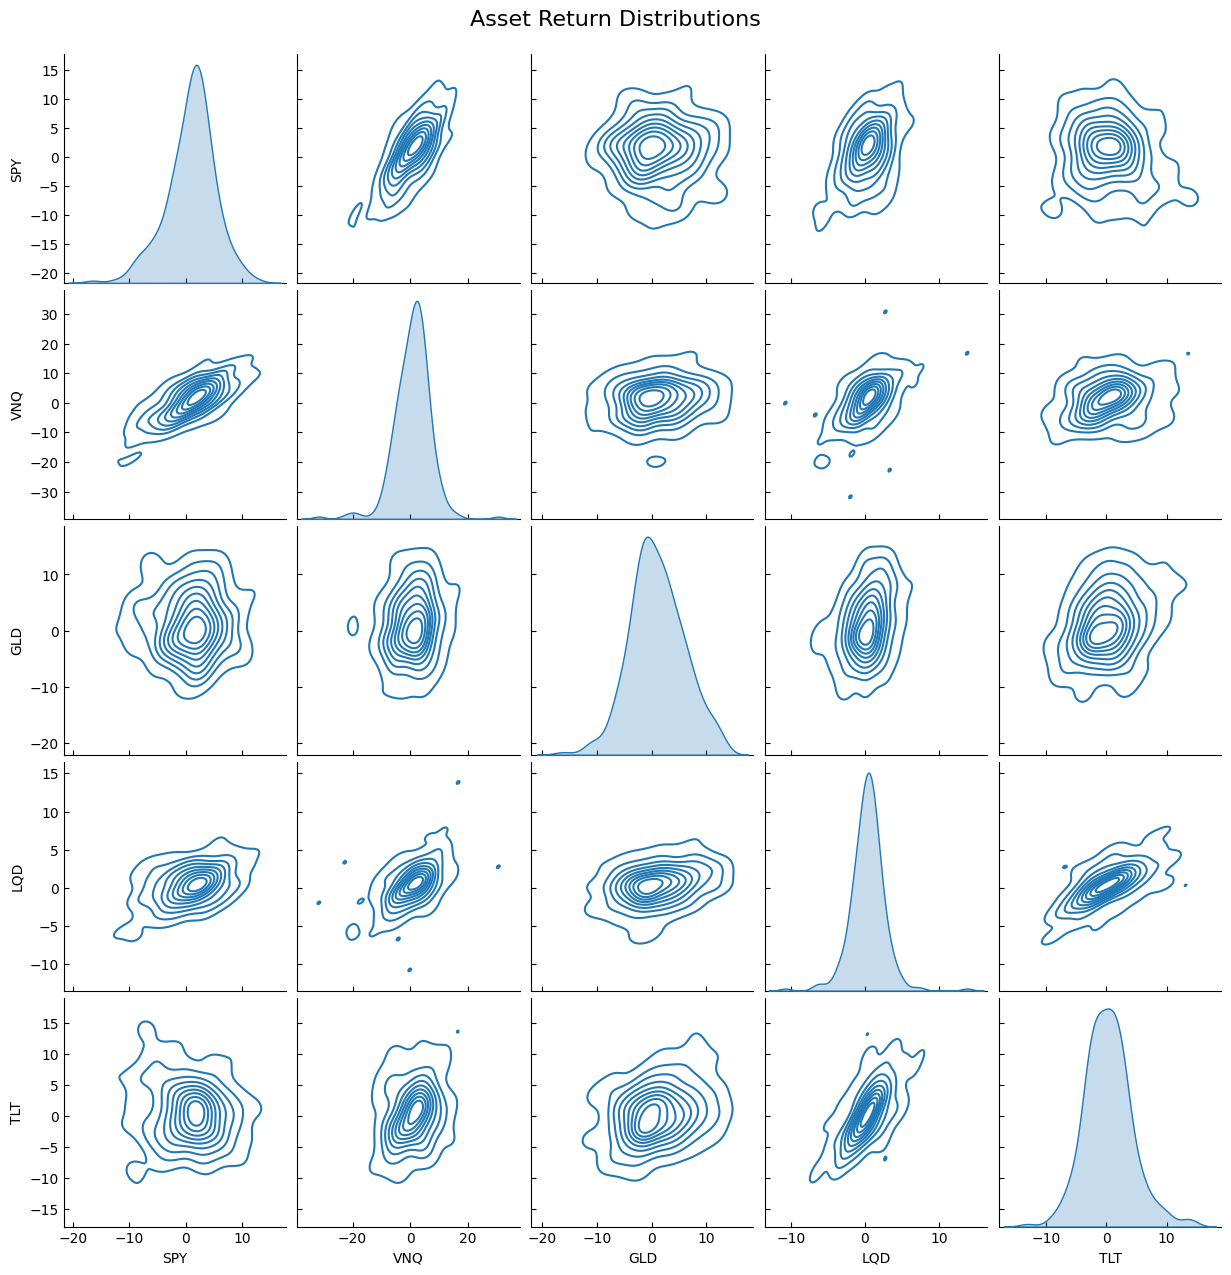

In [176]:
# also visualize all the return distributions as a pairplot
g = sns.pairplot(returns_monthly[universe] * 100., kind='kde')
g.figure.suptitle('Asset Return Distributions', y=1.02)
plt.show()

## Building a Portfolio
We can combine these assets with various weights to construct a portfolio. Again, to approximate a typical retail investor we assume that the portfolio can contain only long positions (positive weights) for any asset. For each portfolio, we can estimate the mean return and variance using the weighted combination of historical data.

We see that varying asset weights gives portfolios with many different risk-return characteristics. The distribution has a sharp edge on the left side. This is the efficient frontier and represents the portfolios that have the optimal set of asset weights that result in the minimum volatility for a given level of return.

In [177]:
# estimate annualized mean returns and covariance
mean_returns = get_annualized_mean_return(returns_monthly[universe])
cov_matrix   = returns_daily[universe].cov() * 252
rf_rate      = rfr_monthly['RF'].mean() * 12

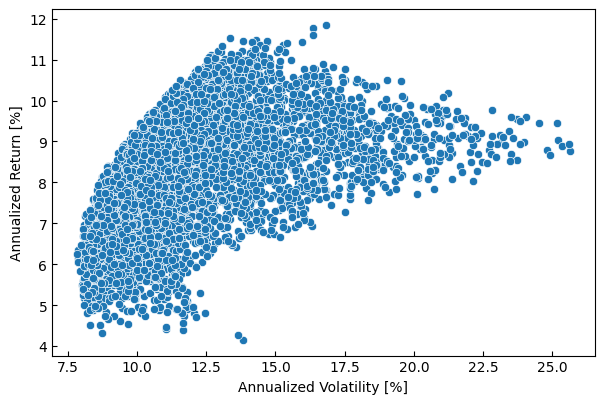

In [178]:
n_random       = 5_000
random_weights = np.random.dirichlet(np.ones(len(universe)), size=n_random)
random_returns = random_weights @ mean_returns.values
random_vols    = np.sqrt(np.sum((random_weights @ cov_matrix.values) * random_weights, axis=1))

fig, ax = plt.subplots()
sns.scatterplot(x=random_vols * 100., y=random_returns * 100., ax=ax)

ax.set_xlabel('Annualized Volatility [%]')
ax.set_ylabel('Annualized Return [%]')

plt.show()

## Portfolio Optimization
We see that varying asset weights in a portfolio gives varying expected performance. Can we optimize these asset weights to create an optimal diversified pertfolio? This can be done using Mean-Variance Optimization (MVO). MVO however requires that we know asses covariances and know what forward returns we can expect for each asset. The asset covariances are calculated from historical data, however we don't have any return forecast. For simplicity, we use the historical sample mean return for each asset.

### Forward Return Estimate Limitation

Roughly ~20 years of monthly data isn't much to pin down a mean return. The standard error of the estimate is comparable to the differences between the mean returns of these assets. Hence, the optimizer will be heavily influenced by the estimation noise rather than real differences in expected return.

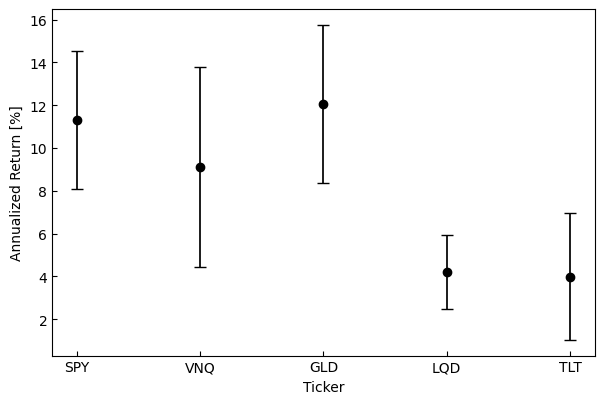

In [179]:
n_obs     = len(returns_monthly[universe])
std_error = (returns_monthly[universe].std() / np.sqrt(n_obs)) * 12 # annualized standard error of the mean

fig, ax = plt.subplots()
ax.errorbar(range(len(mean_returns)), mean_returns * 100., yerr=std_error * 100., fmt='o', capsize=4, elinewidth=1.25, color='k')

ax.set_xticks(range(len(mean_returns)))
ax.set_xticklabels(mean_returns.index.to_list())

ax.set_ylabel('Annualized Return [%]')
ax.set_xlabel('Ticker')

plt.show()

### Portfolio Optimization Based on MOSEK Portfolio Optimization Cookbook
Using the same notation as the MOSEK cookbook (Vector of asset weights $x$, vector of expected returns $\mu$, covariance matrix $\Sigma$, and risk-free rate $r_f$) we can optimize for:

1. **Global Minimum Variance**: the lowest-volatility portfolio, ignoring expected return entirely
$$
\begin{aligned}
\text{minimize} \quad & x^\mathrm{T}\Sigma x \\
\text{subject to} \quad & Ix = 1, \quad x \geq 0
\end{aligned}
$$

2. **Maximum Sharpe Ratio**: the portfolio maximizing risk-adjusted excess return:
$$
\begin{aligned}
\text{maximize} \quad & \dfrac{\mu^\mathrm{T}x - r_f}{\sqrt{x^\mathrm{T}\Sigma x}} \\
\text{subject to} \quad & Ix = 1, \quad x \geq 0
\end{aligned}
$$

In [180]:
def get_portfolio_var(weights, cov_matrix):
    '''Return the expected variance of a portfolio'''
    return weights @ cov_matrix @ weights


def get_portfolio_return(weights, mean_returns):
    '''Returns the expected return of a portfolio'''
    return weights @ mean_returns


def get_sharpe_negative(weights, mean_returns, cov_matrix, risk_free_rate):
        '''Returns the negative sharpe ratio of a portfolio (Not annualized)'''
        portfolio_return = get_portfolio_return(weights, mean_returns)
        portfolio_stdv   = np.sqrt(get_portfolio_var(weights, cov_matrix))

        return -(portfolio_return - risk_free_rate) / portfolio_stdv # negative so minimize finds max sharpe


def solve_min_variance(mean_returns, cov_matrix, target_return=None):
    '''
    Solves for the long-only minimum-variance portfolio weights
    (weights sum to 1, each between 0 and 1). Equality constraint
    is added if target_return is given, otherwise solves for global min 
    '''
    n_assets = len(mean_returns)

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    if target_return is not None:
        constraints.append({'type': 'eq', 'fun': lambda w: w @ mean_returns.values - target_return})

    bounds = [(0, 1)] * n_assets
    x0     = np.repeat(1 / n_assets, n_assets) # equal weight first guess
    result = minimize(get_portfolio_var,
                      x0,
                      args        = cov_matrix.values,
                      method      = 'SLSQP',
                      bounds      = bounds,
                      constraints = constraints,
                      )

    if not result.success:
        raise RuntimeError(f'Min variance solve failed: {result.message}')

    return pd.Series(result.x, index=mean_returns.index)


def solve_max_sharpe(mean_returns, cov_matrix, risk_free_rate):
    '''
    Solves for the long-only max-Sharpe-ratio (tangency) portfolio
    weights (weights sum to 1, each between 0 and 1)
    '''
    n_assets = len(mean_returns)

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

    bounds = [(0, 1)] * n_assets
    x0     = np.repeat(1 / n_assets, n_assets) # equal weight first guess
    result = minimize(get_sharpe_negative,
                      x0,
                      args        = (mean_returns.values, cov_matrix.values, risk_free_rate),
                      method      = 'SLSQP',
                      bounds      = bounds,
                      constraints = constraints,
                      )

    if not result.success:
        raise RuntimeError(f'Max Sharpe solve failed: {result.message}')

    return pd.Series(result.x, index=mean_returns.index)

In [181]:
gmv_weights    = solve_min_variance(mean_returns, cov_matrix)
sharpe_weights = solve_max_sharpe(mean_returns, cov_matrix, risk_free_rate=rf_rate)

print('Weights:\n')
print(pd.DataFrame((gmv_weights * 100.).round(1), columns=['Min Variance [%]']).join(pd.DataFrame((sharpe_weights * 100.).round(1), columns=['Max Sharpe [%]'])))

Weights:

        Min Variance [%]  Max Sharpe [%]
Ticker                                  
SPY                 12.9            39.5
VNQ                  0.0             0.0
GLD                 11.8            37.5
LQD                 65.0             0.0
TLT                 10.3            22.9


### Optimized Portfolio Performance
The optimal weights found for the Min Variance and Max Sharpe portfolios include 0s and some large numbers like 65% corporate bonds in the Min Variance portfolio. We can address this by adding restrictions on maximum asset weighting if desired. Let's see how these portfolios perform against the baseline SPY all-equity portfolio.

Over the ~20 year time horizon we are looking at, SPY outperforms both optimized portfolios in terms of raw CAGR. However, it only overtakes the Max Sharpe portfolio in ~2020 and has a significant -50% drawdown in 2008. The optimized portfolios have significantly less drawdown (~20%) and less volatility which is expected based on the nature of the optimization.

**However**, these optimized portfolios are not realizable! They use future data to create a portfolio in the past so this is not an accurate representation of an investor using an optimized portfolio over this time period. To see the actual performance of using this basic optimization to construct a portfolio, we can use a walk-forward backtest.

              CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
-----------------------------------------------------------------
SPY            10.68        14.87            -50.78        0.65  
Min Variance    5.88         7.82            -21.30        0.55  
Max Sharpe      9.84         9.89            -19.94        0.83  


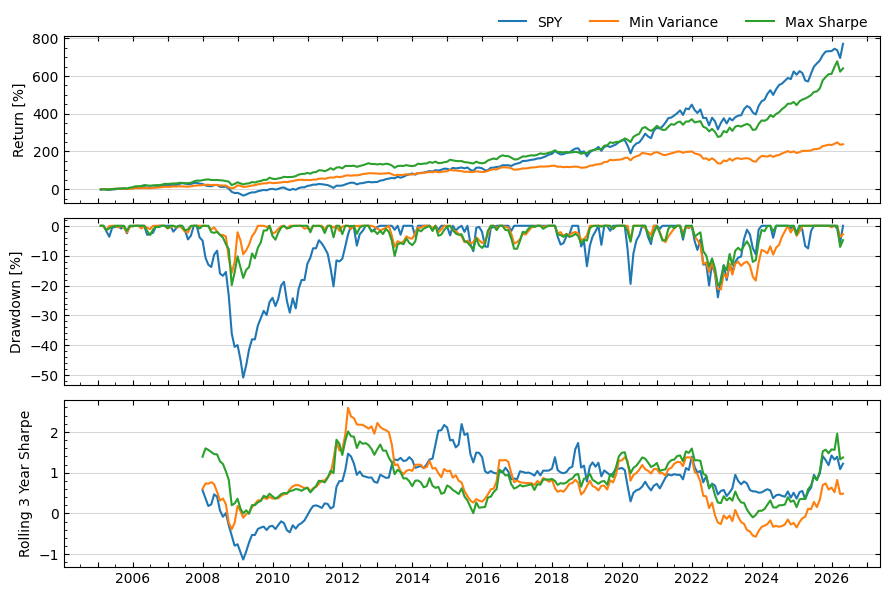

In [182]:
gmv_returns = returns_monthly.mul(pd.Series(gmv_weights)).sum(axis=1)
gmv_returns = pd.DataFrame(gmv_returns, columns=['Min Variance'])

sharpe_returns = returns_monthly.mul(pd.Series(sharpe_weights)).sum(axis=1)
sharpe_returns = pd.DataFrame(sharpe_returns, columns=['Max Sharpe'])

portfolio_df = returns_monthly[['SPY']].copy().join(gmv_returns).join(sharpe_returns)

_ = performance_report(portfolio_df, risk_free_returns=rfr_monthly)

### Optimize for Max Sortino
SPY outperformed the Max Sharpe portfolio as we saw above. Part of this might be that the Sharpe ratio penalizes any volatility. SPY my have a lot of upwards volatility that results in better returns but even this volatility is less preferable for the Sharpe ratio. Before we move to the backtest we can try one more optimization using the Sortino ratio, which only penalizes downward volatility. This can't be written nicely like $x^T\Sigma x$ because we have to selectively choose the downward volatility portions but we can do that with code. Let's quickly see how the Sortino optimization performs.

The Max Sortino portfolio actually outperforms SPY in this window. However, as mentioned before, this comparison is not really practical because of the lookahead bias.

In [183]:
def get_downside_deviation(portfolio_returns, mar=0.):
    '''
    Returns the annualized downside deviation of a portfolio
    return series below a minimum acceptable return (MAR)
    '''
    downside = np.minimum(portfolio_returns - mar, 0)
    return np.sqrt(np.mean(downside**2)) * np.sqrt(12)


def get_sortino_negative(weights, returns_df, risk_free_rate, mar=0.):
    '''Returns the negative annualized sortino ratio of a portfolio'''
    portfolio_returns = returns_df.values @ weights
    portfolio_return  = np.mean(portfolio_returns) * 12
    downside_dev      = get_downside_deviation(portfolio_returns, mar=mar)

    return -(portfolio_return - risk_free_rate) / downside_dev # negative so minimize finds max sortino


def solve_max_sortino(returns_df, risk_free_rate, mar=0.):
    '''
    Solves for the long-only max-Sortino-ratio portfolio weights
    (weights sum to 1, each between 0 and 1)
    '''
    n_assets = returns_df.shape[1]

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

    bounds = [(0, 1)] * n_assets
    x0     = np.repeat(1 / n_assets, n_assets) # equal weight first guess
    result = minimize(get_sortino_negative,
                      x0,
                      args        = (returns_df, risk_free_rate, mar),
                      method      = 'SLSQP',
                      bounds      = bounds,
                      constraints = constraints,
                      )

    if not result.success:
        raise RuntimeError(f'Max Sortino solve failed: {result.message}')

    return pd.Series(result.x, index=returns_df.columns)

In [184]:
sortino_weights = solve_max_sortino(returns_monthly[universe], risk_free_rate=rf_rate)

print('Weights:\n')
print(pd.DataFrame((gmv_weights * 100.).round(1), columns=['Min Variance [%]'])
      .join(pd.DataFrame((sharpe_weights * 100.).round(1), columns=['Max Sharpe [%]']))
      .join(pd.DataFrame((sortino_weights * 100.).round(1), columns=['Max Sortino [%]'])))

Weights:

        Min Variance [%]  Max Sharpe [%]  Max Sortino [%]
Ticker                                                   
SPY                 12.9            39.5             45.7
VNQ                  0.0             0.0              0.0
GLD                 11.8            37.5             44.2
LQD                 65.0             0.0              0.0
TLT                 10.3            22.9             10.0


              CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
-----------------------------------------------------------------
SPY            10.68        14.87            -50.78        0.65  
Min Variance    5.88         7.82            -21.30        0.55  
Max Sharpe      9.84         9.89            -19.94        0.83  
Max Sortino    10.82        10.81            -23.12        0.86  


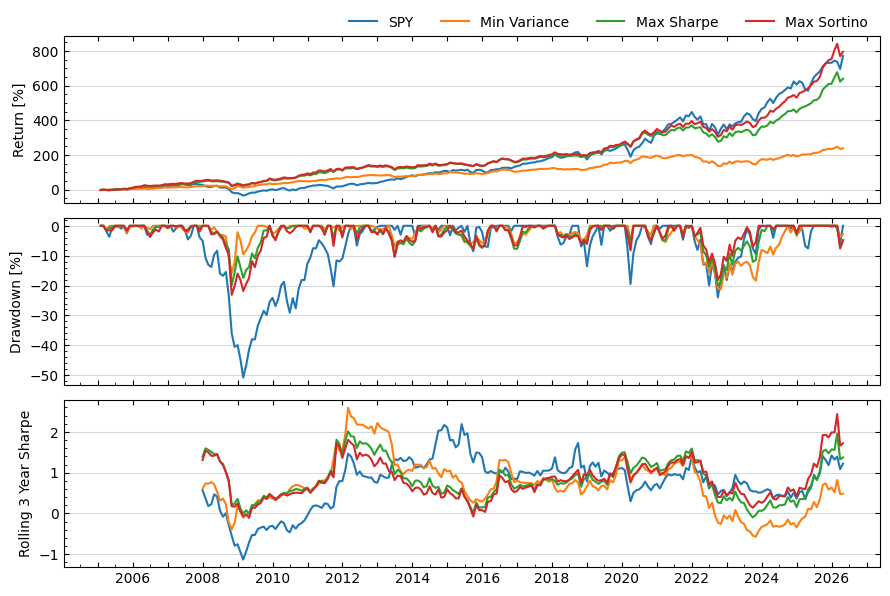

In [185]:
sortino_returns = returns_monthly.mul(pd.Series(sortino_weights)).sum(axis=1)
sortino_returns = pd.DataFrame(sortino_returns, columns=['Max Sortino'])

portfolio_df = returns_monthly[['SPY']].copy().join(gmv_returns).join(sharpe_returns).join(sortino_returns)

_ = performance_report(portfolio_df, risk_free_returns=rfr_monthly)

## Backtesting
To see if portfolio optimization and rebalancing would actually work in practice, we run a walk-forward backtest. Each month we will rebalance the portfolio based on an MVO using a 5 year lookback window to estimate the mean returns and covariance.

Looking at the results it seems that again SPY alone outperforms the optimized portfolios. However, we should note that because of the 5 year burn-in, the 2008 period where SPY had a significant drawdown is not included in the backtest which is a factor in the SPY outperformance.

In [186]:
def walk_forward_weights(returns_monthly, returns_daily, rfr_monthly, universe, lookback_years=5, strategy='max_sharpe'):
    '''
    Calculate optimal portfolio weights for each month using data that
    was actually available on that month (no lookahead bias). Returns
    a dataframe of portfolio weights
    '''
    min_months   = lookback_years * 12
    weights_list = []

    for date in returns_monthly.index:
        window_start = date - relativedelta(years=lookback_years)

        # get data in the window (only what was available before the current date)
        monthly_window = returns_monthly.loc[(returns_monthly.index >= window_start) & (returns_monthly.index < date), universe]
        daily_window   = returns_daily.loc[(returns_daily.index >= window_start) & (returns_daily.index < date), universe]
        rfr_window     = rfr_monthly.loc[(rfr_monthly.index >= window_start) & (rfr_monthly.index < date)]

        if len(monthly_window) < min_months:
            continue

        mean_returns = get_annualized_mean_return(monthly_window)
        cov_matrix   = daily_window.cov() * 252
        rf_rate      = rfr_window['RF'].mean() * 12

        if strategy == 'max_sharpe':
            weights = solve_max_sharpe(mean_returns, cov_matrix, risk_free_rate=rf_rate)
        elif strategy == 'min_variance':
            weights = solve_min_variance(mean_returns, cov_matrix)
        elif strategy == 'max_sortino':
            weights = solve_max_sortino(monthly_window, risk_free_rate=rf_rate)

        weight_dict         = weights.to_dict()
        weight_dict['date'] = date
        weights_list.append(weight_dict)

    return pd.DataFrame(weights_list).set_index('date')

                          CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
-----------------------------------------------------------------------------
SPY                        14.03        14.43            -23.93        0.89  
Walk-Forward Min Var        6.59         7.32            -21.52        0.73  
Walk-Forward Max Sharpe    10.53         9.25            -23.17        1.00  
Walk-Forward Max Sortino   10.90        10.09            -21.35        0.95  


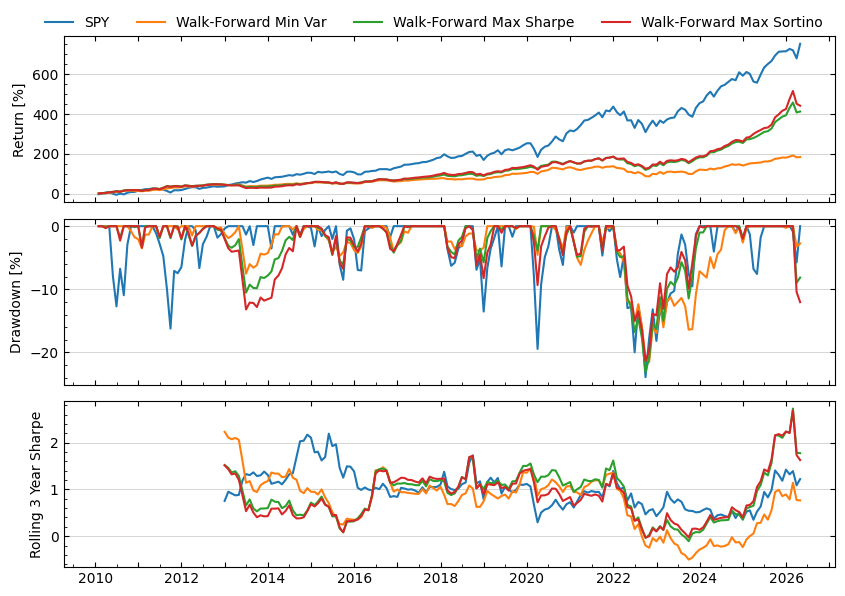

In [187]:
LOOKBACK_YEARS = 5

wf_weights_sharpe  = walk_forward_weights(returns_monthly, returns_daily, rfr_monthly,
                                          universe, lookback_years=LOOKBACK_YEARS, strategy='max_sharpe')
wf_weights_gmv     = walk_forward_weights(returns_monthly, returns_daily, rfr_monthly,
                                          universe, lookback_years=LOOKBACK_YEARS, strategy='min_variance')
wf_weights_sortino = walk_forward_weights(returns_monthly, returns_daily, rfr_monthly,
                                          universe, lookback_years=LOOKBACK_YEARS, strategy='max_sortino')

# min_count=1 ensures months with no weights (burn-in period) produce nan rather than 0, so dropna() trims all series to the same start date
wf_returns_sharpe  = (returns_monthly[universe] * wf_weights_sharpe).sum(axis=1, min_count=1).rename('Walk-Forward Max Sharpe')
wf_returns_gmv     = (returns_monthly[universe] * wf_weights_gmv).sum(axis=1, min_count=1).rename('Walk-Forward Min Var')
wf_returns_sortino = (returns_monthly[universe] * wf_weights_sortino).sum(axis=1, min_count=1).rename('Walk-Forward Max Sortino')

backtest_df = returns_monthly[['SPY']].join([wf_returns_gmv, wf_returns_sharpe, wf_returns_sortino]).dropna()
_ = performance_report(backtest_df, risk_free_returns=rfr_monthly.loc[backtest_df.index])

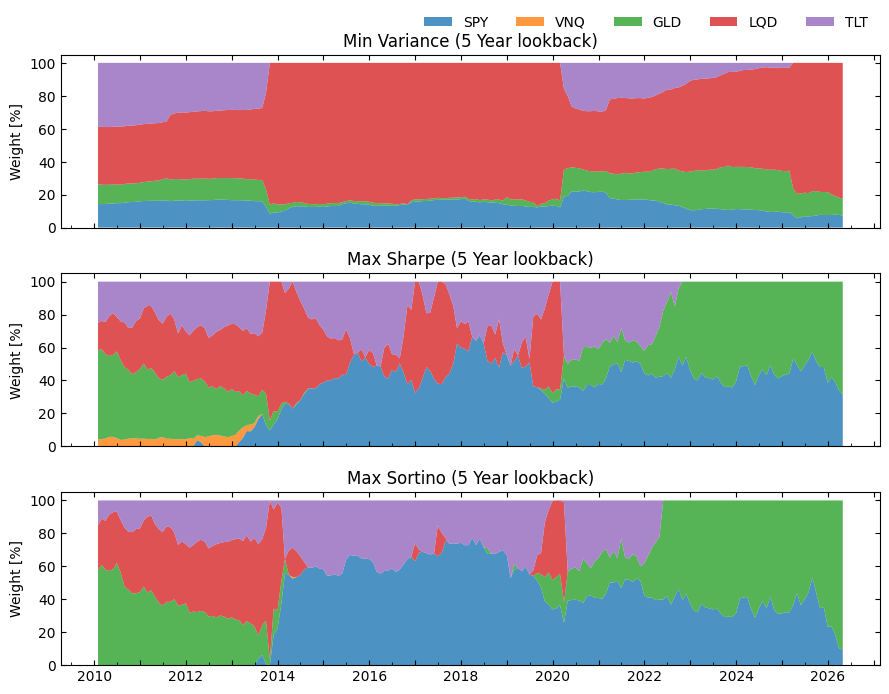

In [188]:
# plot how weights evolved over time
fig, axs = plt.subplots(nrows=3, figsize=(9, 7), sharex=True)

weights_list = [wf_weights_gmv, wf_weights_sharpe, wf_weights_sortino]
titles       = [f'Min Variance ({LOOKBACK_YEARS} Year lookback)',
                f'Max Sharpe ({LOOKBACK_YEARS} Year lookback)',
                f'Max Sortino ({LOOKBACK_YEARS} Year lookback)',
                ]

for i, ax in enumerate(axs):
    ax.stackplot(weights_list[i].index, [weights_list[i][t] * 100 for t in universe],
                 labels=universe, alpha=0.8)
    ax.set_ylabel('Weight [%]')
    ax.set_title(titles[i])
    set_date_ticks(ax)
    ax.tick_params(top=True, bottom=True, left=True, right=True)

axs[0].legend(loc='upper right', bbox_to_anchor=(1, 1.3), ncols=len(universe), frameon=False)
fig.tight_layout()
plt.show()

### How Much can Accurate Forecasts Help?

Every backtest above used the trailing historical mean as the only estimate for expected return. MVO is only ever as good as the input. What happens if we actually had some real forecasting skill?

To make a simple forecasting model we can use a blend of the real future return with the historical mean return. For each rebalance date in the walk-forward backtest, we blend the trailing historical mean with the actual realized return that month mixed by a forecast weight. A weight of 0 recovers the walk-forward Max Sharpe backtest above (no skill) and a weight of 1 is a portfolio built with perfect foresight of the next period month return. This is an unrealistic upper bound since it uses direct information from the future that no real forecaster ever has. Sweeping this weight from 0 to 1 shows how quickly walk-forward performance improves as assumed forecast skill increases.

Note: The sudden performance increase from even a small forecast weight illustrates how much leaking future information can influcence a backtest. Even a small contribution of future knowledge results in dramatic performance improvements.

In [ ]:
def walk_forward_weights_forecast(returns_monthly, returns_daily, rfr_monthly, universe,
                                   lookback_years=5, forecast_weight=0.):
    '''
    Same as walk_forward_weights(strategy='max_sharpe'), except the mean
    return estimate for each month blends the trailing historical mean with
    that month's actual realized return
    '''
    min_months   = lookback_years * 12
    weights_list = []

    for date in returns_monthly.index:
        window_start = date - relativedelta(years=lookback_years)

        # get data in the window (only what was available before the current date)
        monthly_window = returns_monthly.loc[(returns_monthly.index >= window_start) & (returns_monthly.index < date), universe]
        daily_window   = returns_daily.loc[(returns_daily.index >= window_start) & (returns_daily.index < date), universe]
        rfr_window     = rfr_monthly.loc[(rfr_monthly.index >= window_start) & (rfr_monthly.index < date)]

        if len(monthly_window) < min_months:
            continue

        historical_mean = monthly_window.mean()
        actual_return   = returns_monthly.loc[date, universe]
        blended_mean    = (1 - forecast_weight) * historical_mean + forecast_weight * actual_return

        mean_returns = blended_mean * 12
        cov_matrix   = daily_window.cov() * 252
        rf_rate      = rfr_window['RF'].mean() * 12

        weights = solve_max_sharpe(mean_returns, cov_matrix, risk_free_rate=rf_rate)

        weight_dict         = weights.to_dict()
        weight_dict['date'] = date
        weights_list.append(weight_dict)

    return pd.DataFrame(weights_list).set_index('date')

        CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
-----------------------------------------------------------
w=0.00   10.53         9.25            -23.17        1.00  
w=0.01   12.02         9.29            -21.72        1.14  
w=0.02   13.50         9.34            -20.29        1.28  
w=0.05   17.91         9.56            -15.81        1.66  
w=0.10   25.83         9.93            -8.14         2.27  
w=0.20   37.37        10.20            -6.85         3.10  
w=0.50   46.89        10.62            -6.85         3.63  
w=1.00   49.91        10.92            -6.85         3.72  


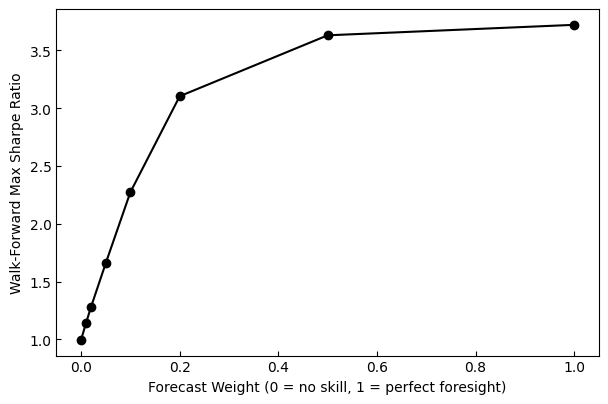

In [203]:
forecast_weights = [0., 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

wf_returns_by_weight = {}
for forecast_weight in forecast_weights:
    wf_weights = walk_forward_weights_forecast(returns_monthly, returns_daily, rfr_monthly, universe,
                                                lookback_years=LOOKBACK_YEARS, forecast_weight=forecast_weight)
    wf_returns = (returns_monthly[universe] * wf_weights).sum(axis=1, min_count=1)

    wf_returns_by_weight[f'w={forecast_weight:.2f}'] = wf_returns

forecast_backtest_df = pd.DataFrame(wf_returns_by_weight).dropna()

forecast_stats = get_summary_stats(forecast_backtest_df, rfr_monthly.loc[forecast_backtest_df.index])
print_summary_stats(forecast_stats)

fig, ax = plt.subplots()
ax.plot(forecast_weights, forecast_stats.loc['Sharpe'], marker='o', color='k')

ax.set_xlabel('Forecast Weight (0 = no skill, 1 = perfect foresight)')
ax.set_ylabel('Walk-Forward Max Sharpe Ratio')

plt.show()

        CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
-----------------------------------------------------------
SPY      14.03        14.43            -23.93        0.89  
w=0.00   10.53         9.25            -23.17        1.00  
w=0.01   12.02         9.29            -21.72        1.14  
w=0.02   13.50         9.34            -20.29        1.28  
w=0.05   17.91         9.56            -15.81        1.66  


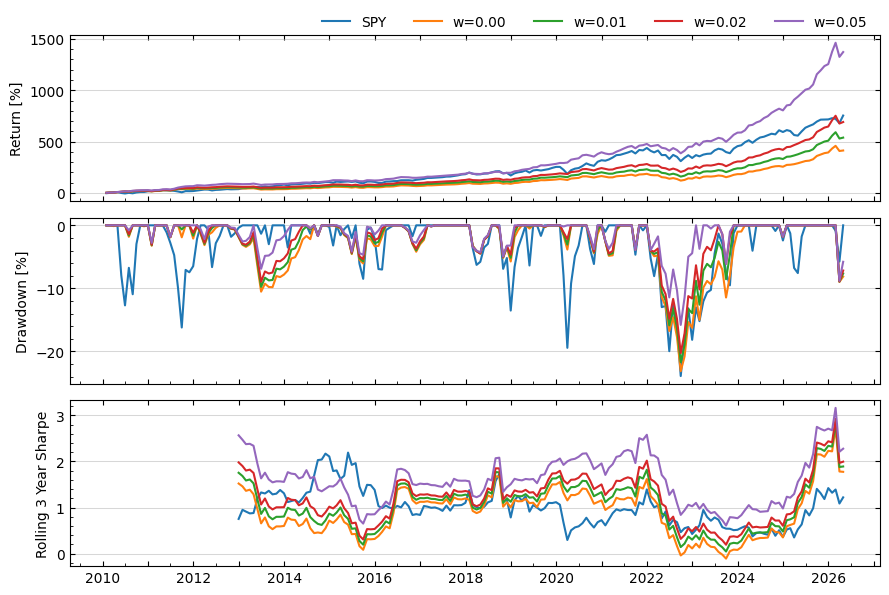

In [205]:
backtest_df = returns_monthly[['SPY']]

for forecast_weight in ['0.00', '0.01', '0.02', '0.05']:
    wf_returns  = (forecast_backtest_df[f'w={forecast_weight}']).rename(f'w={forecast_weight}')
    backtest_df = backtest_df.join([wf_returns]).dropna()

_ = performance_report(backtest_df, risk_free_returns=rfr_monthly.loc[backtest_df.index])

## Limitations

### Do Correlations Hold Up in a Crisis?

The correlation matrix above is calculated over the full sample which is dominated by calm periods. The point of diversifying a portfolio is to limit exposure to individual risky assets by combining multiple uncorrelated assets together. However, when there is a market crisis and you are banking on diversification the most, it may not really be there to protect you. In a broad market crisis, many risky assets tend to get pulled down together and the correlations, which may have been historically low, can quickly rise, defeating the idea of diversification as a hedge.

To demonstrate this we can look at the 60 day rolling correlation of each asset to SPY around a time of crisis. We look at the 2008 crash for example and see that "diversifying" assets diversify less exactly when it counts. Furthermore, we see that the correlation between assets changes quite a bit over time. MVO assumes the covariance matrix is stable over time which it is clearly not.

In the figure below we see that leading up to the crash, many of the assets are uncorrelated or have negative correlations with SPY. In September 2008 when the crash happened, we see that corporate bonds (LQD) and gold (GLD), which had lower correlations with SPY both jumped up to ~0.5. REITs (VNQ) were continuously correlated with SPY. Treasuries (TLT) remain negatively correlated with SPY throughout and even show a small inverse shift when the crash happens.

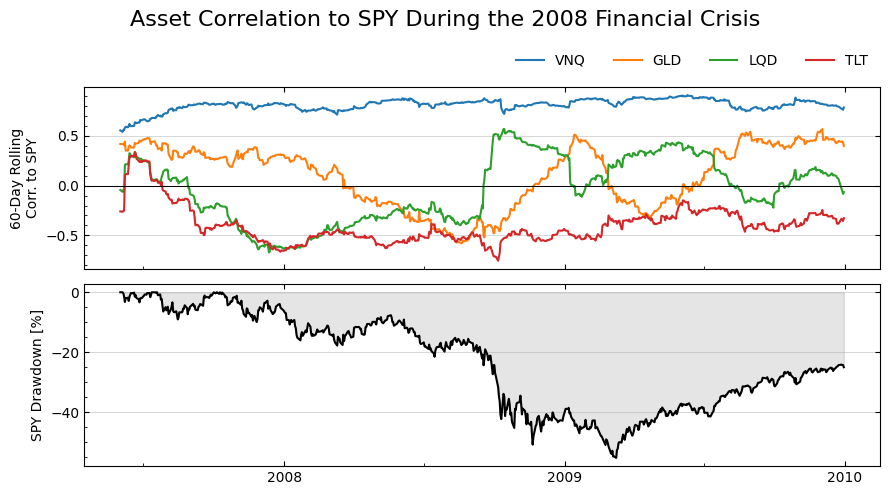

In [ ]:
CRISIS_START = '2007-06-01'
CRISIS_END   = '2009-12-31'

rolling_corr_daily = get_rolling_correlation(returns_daily[universe], returns_daily['SPY'], window=60).drop(columns=['SPY'])
spy_drawdown_daily = get_drawdown(returns_daily[['SPY']])['SPY']

rolling_corr_crisis = rolling_corr_daily.loc[CRISIS_START:CRISIS_END]
spy_drawdown_crisis = spy_drawdown_daily.loc[CRISIS_START:CRISIS_END]

fig, axs = plt.subplots(nrows=2, figsize=(9, 5), sharex=True)

ax = axs[0]
for ticker in rolling_corr_crisis.columns:
    ax.plot(rolling_corr_crisis[ticker], label=ticker)
ax.axhline(0, color='k', linewidth=0.75)
ax.set_ylabel('60-Day Rolling\nCorr. to SPY')
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.25), ncols=4, frameon=False)

ax = axs[1]
ax.plot(spy_drawdown_crisis * 100., color='k')
ax.fill_between(spy_drawdown_crisis.index, spy_drawdown_crisis * 100., 0, color='k', alpha=0.1)
ax.set_ylabel('SPY Drawdown [%]')

for ax in axs:
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(top=True, bottom=True, left=True, right=True)
    ax.grid(axis='y', linewidth=0.75, alpha=0.5)
    set_date_ticks(ax, label_every=1)

fig.suptitle('Asset Correlation to SPY During the 2008 Financial Crisis')

fig.tight_layout()
plt.show()